In [1]:
import numpy as np
import matplotlib.pyplot as plt
from h5py import File

from IPython.display import display
from plot_utils import *
import flowi

%matplotlib inline
%load_ext autoreload
%autoreload 2

/Users/rstiskalek/Projects/FlowIntegrator/venv_flowi/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_manticore_velocity(base_folder, simulation_number):
    loader = flowi.ManticoreLoader(base_folder, simulation_number)
    return loader.load_velocity_field(), loader.boxsize

velocity_field, boxsize = load_manticore_velocity("/Users/rstiskalek/Projects/FlowIntegrator/data/ManticoreLocal_N256", 0)

In [ ]:
velocity_field

array([[[[-1.19370621e+02, -1.33178802e+02, -1.50120010e+02, ...,
          -1.40582611e+02, -1.66225769e+02, -1.90898499e+02],
         [-1.30234283e+02, -1.27156860e+02, -1.43248428e+02, ...,
          -6.27519531e+01, -1.05180908e+02, -2.03527878e+02],
         [-1.40372726e+02, -1.36325775e+02, -1.38816162e+02, ...,
          -3.58212433e+01, -7.44803467e+01, -9.35274200e+01],
         ...,
         [-5.99737816e+01, -1.05996597e+02, -5.82427788e+01, ...,
          -2.08086014e+02, -1.80081772e+02, -6.09883575e+01],
         [-2.58598537e+01, -1.15706291e+02, -1.69664154e+02, ...,
          -1.91256729e+02, -1.79306122e+02, -7.75908890e+01],
         [-1.04294434e+02, -1.27789780e+02, -1.57778122e+02, ...,
          -1.74786438e+02, -1.66056396e+02, -1.27452255e+02]],

        [[-1.41624084e+02, -1.25439171e+02, -1.18106865e+02, ...,
          -9.33979492e+01, -9.77862091e+01, -1.56938660e+02],
         [-1.18440208e+02, -1.19012871e+02, -1.27179848e+02, ...,
          -1.11080338e

In [4]:
with File("/Users/rstiskalek/Downloads/precomputed_los_manticore_2MPP_MULTIBIN_N256_DES_V2_CF4_W1_noMNR_double_powerlaw_beta_1.0.hdf5", 'r') as f:
    grp = f["samples"]
    Vext = grp["Vext"][...]

In [6]:
np.mean(Vext, axis=0)

array([-29.389921, -17.852118, -82.94362 ], dtype=float32)

In [29]:
def load_manticore_velocity(base_folder, simulation_number):
    loader = flowi.ManticoreLoader(base_folder, simulation_number)
    return loader.load_velocity_field(), loader.boxsize


velocity_field, boxsize = load_manticore_velocity("/Users/rstiskalek/Projects/FlowIntegrator/data/ManticoreLocal_N256", 0)

resolution = velocity_field.shape[-1]
obs_pos = np.full((3,), boxsize / 2)

ngrid = velocity_field.shape[-1]
ds = 0.05 * boxsize / ngrid

velocity_field = flowi.smooth_velocity_field_gaussian(velocity_field, boxsize, sigma=3)


In [34]:
num_steps = 25000
intg = flowi.Integrator(velocity_field, boxsize, num_steps, ds)
x0 = flowi.create_initial_positions(
    boxsize, ngrid, N=100, observer_location=obs_pos,
    max_distance=200)

2025-11-25 10:34:52 Filtered to 106000 particles within 200 Mpc/h of observer.
2025-11-25 10:34:52 Initialized 106000 particles on device.


In [35]:
xf, vf, dx_step = intg.run(x0)

2025-11-25 10:34:54 Compiling and running JIT-compiled integration...


Integrating: 100%|██████████| 25000/25000 [00:45<00:00, 555.24it/s]

2025-11-25 10:35:39 Integration complete.
2025-11-25 10:35:39 Fraction of particles with displacement over 2500 steps less than half a resolution element (1.33e+00): 100.00%


In [4]:
from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=100, Om0=0.306)

cosmo.critical_density(-0.5).to("Msun / Mpc3")

<Quantity 2.03226195e+11 solMass / Mpc3>

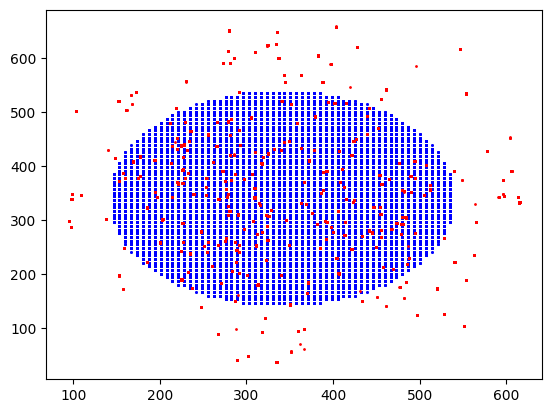

In [36]:
plt.figure()
plt.scatter(x0[:, 0], x0[:, 1], c='blue', label='Initial Positions', s=1)
plt.scatter(xf[:, 0], xf[:, 1], c='red', label='Final Positions', s=1)
plt.show()

In [37]:
res = intg.get_cluster_info_voxel(xf, dx_step, )

2025-11-25 10:35:43 Voxelizing 106000 converged particles into a 256^3 grid with min_count=1.
2025-11-25 10:35:43 Found 352 occupied voxels.


In [38]:
ga_pos = np.asarray([314.1391906738281, 331.3797607421875, 317.62042236328125])

In [43]:
np.argsort([np.linalg.norm(r.centroid - ga_pos) for r in res])

array([ 13,  27, 127, 163, 215, 250,  49, 170,  35,  55,  43, 194, 187,
       160,   3,  97,  28, 143, 136, 162, 201, 165, 218, 226,  34,  98,
        23,  96, 146,  38,  67, 224,   0, 204,  88, 242,  95, 103,  76,
        82, 188, 164,  70, 186,  37, 119,  25, 139,  17,  94, 130, 141,
       168, 105, 172,  86,  18,  79,  31, 115, 192,  84, 110, 198,  51,
       177,   6,  77, 149,  90,  14,  21,  68, 211, 114, 121, 134, 154,
       128, 106, 214,  78,  60, 118,  24,  83, 221,  75,  32,  50, 180,
       183, 151,  92, 120, 189,  30,  61, 102,  73, 200, 131, 144, 145,
        54, 190,  63, 184,  85, 156,  52, 132, 157,  26, 158,  16,  22,
       243, 126, 248, 161,  99, 197,   7,  91, 174, 112,  33,  19, 108,
       124, 176, 281,  87, 212, 100, 191,   2,  80, 109,  45, 147,  53,
         5, 140, 181,  59, 213,  15, 173, 169,   4, 205, 123, 159, 220,
         9, 252, 280, 179, 113, 111,  65,  56, 238, 254, 225,  93,  89,
       178,  57, 262,  20, 258, 253, 232,  48, 185,  62, 245, 10

In [54]:
X = x0[res[13].members]

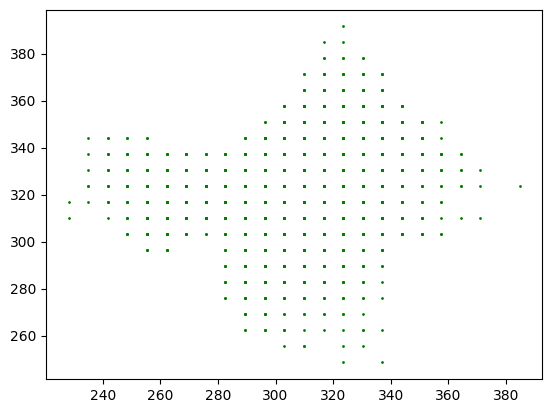

In [56]:
plt.figure()
plt.scatter(X[:, 0], X[:, 2], c='green', label='GA Cluster Initial Positions', s=1)
plt.show()

In [50]:
res[13].positions

AttributeError: 'AttractorInfo' object has no attribute 'positions'

In [18]:
res.centroids

Array([[366.72076, 370.13196, 374.95544],
       [315.8819 , 333.53018, 319.2398 ],
       [329.38052, 318.6087 , 298.14557],
       [328.38028, 342.01645, 342.92523],
       [308.5217 , 325.37653, 316.78967],
       [349.98224, 352.21124, 337.80127],
       [278.32657, 289.39517, 348.98453],
       [296.33862, 329.2552 , 326.91202],
       [391.7634 , 389.97568, 350.73654],
       [348.54465, 300.32828, 358.23044],
       [278.72717, 343.96295, 365.42737],
       [279.0944 , 327.13788, 375.76   ],
       [313.58643, 274.58328, 401.42645],
       [370.51773, 310.15118, 350.54102],
       [332.4687 , 379.23517, 386.73572],
       [323.99503, 262.86142, 310.61395],
       [342.24634, 347.84082, 350.33002],
       [344.47202, 360.02216, 294.284  ],
       [366.83786, 314.5706 , 343.11874],
       [373.55472, 360.68942, 295.08304],
       [278.79404, 317.7528 , 321.8294 ],
       [313.68396, 371.7544 , 357.31485],
       [377.63074, 298.21222, 337.8837 ],
       [278.1771 , 341.5975 , 344.

In [172]:
X = res.to_galactic(obs_pos, input_frame='icrs')
counts = res.counts


r = X[:, 0]

# m = X[:, 0] < 200

# X = X[m]
# counts = counts[m]

In [173]:
np.where(r < 50)

(array([0]),)

In [174]:
res[187].to_galactic(obs_pos, input_frame='icrs')

IndexError: list index out of range

In [175]:
ks = res[0].members

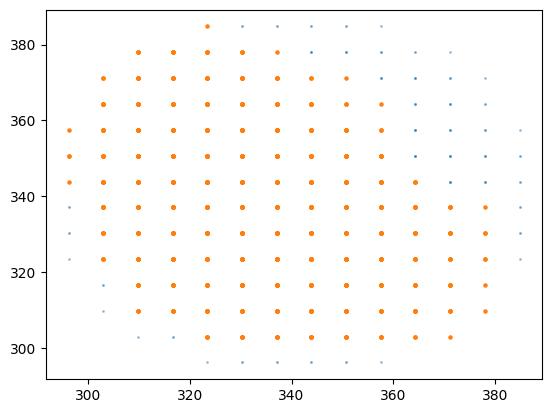

In [176]:
plt.figure()
plt.scatter(x0[:, 0], x0[:, 1], s=1, alpha=0.1)
plt.scatter(x0[ks, 0], x0[ks, 1], s=5)


plt.show()

In [181]:
res[0].to_galactic(obs_pos, input_frame='icrs')

<SkyCoord (Galactic): (l, b, distance) in (deg, deg, Mpc)
    (312.17266839, 29.0462891, 42.80442662)>

In [182]:
res.counts

Array([747, 636,  75,  65,  50,  46,  18,   2], dtype=int32)

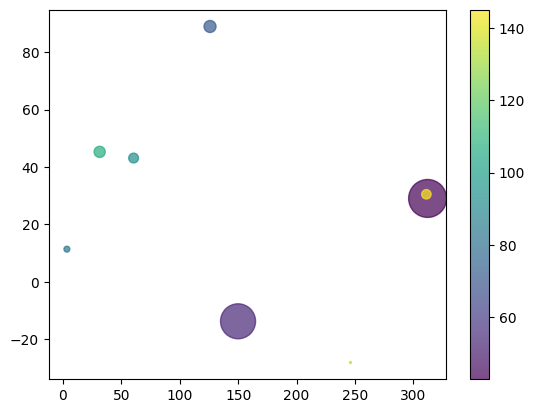

In [183]:
m = X[:, 0] < 300

# m &= X[:, 0] > 40

plt.figure()
plt.scatter(X[m, 1], X[m, 2], s=counts[m], c=X[m, 0], cmap='viridis', alpha=0.7)
plt.colorbar()

plt.show()

In [21]:
res[14].to_galactic(obs_pos, input_frame='galactic')

<SkyCoord (Galactic): (l, b, distance) in (deg, deg, Mpc)
    (162.75814684, 22.13137596, 105.26199285)>

In [56]:
res[0]

AttractorInfo(centroid=Array([200.77785, 200.77783, 200.77788], dtype=float32), count=27000)

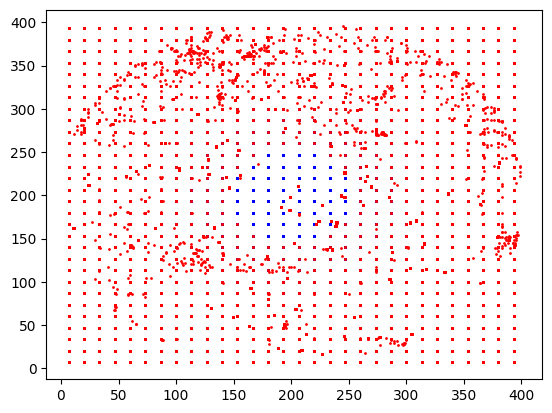

In [146]:
plt.figure()
plt.scatter(x0[:, 0], x0[:, 1], c='blue', label='Initial Positions', s=1)

plt.scatter(xf[:, 0], xf[:, 1], c='red', label='Final Positions', s=1)



plt.show()